# XGBoost Demo: Airline Passengers Forecasting
This notebook demonstrates feature engineering for time series data and training an XGBoost regressor on the classic Airline Passengers dataset.

Key steps:
- load the dataset
- create rolling, lag, detrended, and seasonality features
- split into train/test sets
- apply time-series cross-validation
- train and evaluate an XGBoost model

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

try:
    import xgboost as xgb
except Exception as exc:
    raise ImportError(
        "Unable to import xgboost. On macOS you may need to install the OpenMP runtime first: `brew install libomp`. "
        "Then restart the notebook kernel and rerun. "
        f"Original error: {exc}"
    ) from exc

# Load the Airline Passengers dataset
url = "https://storage.googleapis.com/edulabs-public-datasets/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=["Month"])
df = df.rename(columns={"Passengers": "passengers"})
df = df.set_index("Month").sort_index()
df.head()

,passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## 1. Inspect the series
We verify the data structure and observe the strong seasonal pattern and upward trend.

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None
       passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


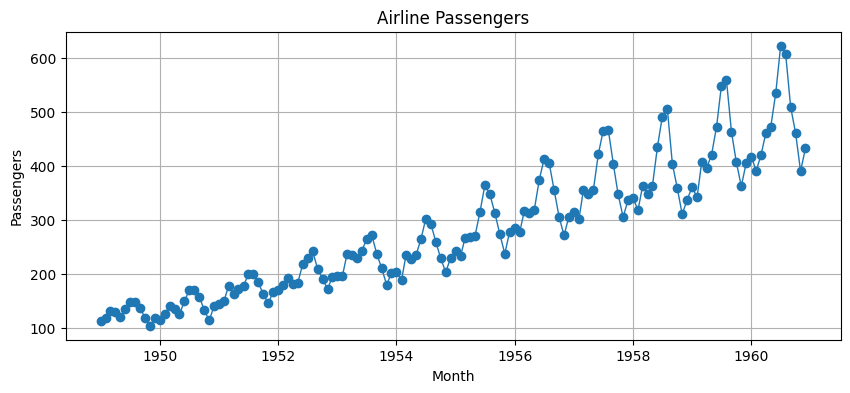

In [7]:
print(df.info())
print(df.describe())

plt.figure(figsize=(10, 4))
plt.plot(df.index, df["passengers"], marker="o", linewidth=1)
plt.title("Airline Passengers")
plt.ylabel("Passengers")
plt.xlabel("Month")
plt.grid(True)
plt.show()

## 2. Feature Engineering
We add:
- rolling averages to capture trend and local smoothing
- detrended signal as a feature
- lag features for autoregression
- seasonality features using month encoding
- future target shifted by one month

In [8]:
# Rolling averages for trend capture
rolling_windows = [3, 6, 12]
for window in rolling_windows:
    df[f"rolling_{window}"] = df["passengers"].rolling(window=window).mean()

# Detrended signal based on 12-month rolling mean
df["trend_12"] = df["passengers"].rolling(window=12, center=False).mean()
df["detrended"] = df["passengers"] - df["trend_12"]

# Lag features
lags = [1, 2, 12]
for lag in lags:
    df[f"lag_{lag}"] = df["passengers"].shift(lag)

# Seasonality features
df["month"] = df.index.month

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["quarter"] = df.index.quarter

df["quarter_sin"] = np.sin(2 * np.pi * (df["quarter"] - 1) / 4)
df["quarter_cos"] = np.cos(2 * np.pi * (df["quarter"] - 1) / 4)

# Target: next-month passengers
# We use current features to predict the following month

df["target"] = df["passengers"].shift(-1)

# Drop rows with NaN values created by lag/rolling/target shift
model_df = df.dropna().copy()

model_df.head()

,passengers,rolling_3,rolling_6,rolling_12,trend_12,detrended,lag_1,lag_2,lag_12,month,month_sin,month_cos,quarter,quarter_sin,quarter_cos,target
Month,,,,,,,,,,,,,,,,
1950-01-01,115,112.333333,123.333333,126.916667,126.916667,-11.916667,118.0,104.0,112.0,1,0.500000,8.660254e-01,1,0.0,1.000000e+00,126.0
1950-02-01,126,119.666667,119.666667,127.583333,127.583333,-1.583333,115.0,118.0,118.0,2,0.866025,5.000000e-01,1,0.0,1.000000e+00,141.0
1950-03-01,141,127.333333,120.500000,128.333333,128.333333,12.666667,126.0,115.0,132.0,3,1.000000,6.123234e-17,1,0.0,1.000000e+00,135.0
1950-04-01,135,134.000000,123.166667,128.833333,128.833333,6.166667,141.0,126.0,129.0,4,0.866025,-5.000000e-01,2,1.0,6.123234e-17,125.0
1950-05-01,125,133.666667,126.666667,129.166667,129.166667,-4.166667,135.0,141.0,121.0,5,0.500000,-8.660254e-01,2,1.0,6.123234e-17,149.0


## 3. Train/Test Split
We use the final year as a holdout test set and keep the earlier months for training.

In [9]:
# Use the last 12 months as test set
n_test = 12
train_df = model_df.iloc[:-n_test].copy()
test_df = model_df.iloc[-n_test:].copy()

feature_columns = [
    "rolling_3",
    "rolling_6",
    "rolling_12",
    "trend_12",
    "detrended",
    "lag_1",
    "lag_2",
    "lag_12",
    "month_sin",
    "month_cos",
    "quarter_sin",
    "quarter_cos",
]

X_train = train_df[feature_columns]
y_train = train_df["target"]
X_test = test_df[feature_columns]
y_test = test_df["target"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (119, 12)
Test shape: (12, 12)


## 4. Cross-Validation with TimeSeriesSplit
We evaluate model stability using a rolling window cross-validation split.

In [11]:
# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for fold, (train_index, val_index) in enumerate(tscv.split(X_train), start=1):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        objective="reg:squarederror",
        verbosity=0,
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    rmse_scores.append(rmse)
    print(f"Fold {fold}: RMSE = {rmse:.3f}")

print(f"Average CV RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")

Fold 1: RMSE = 49.175
Fold 2: RMSE = 26.314
Fold 3: RMSE = 77.346
Fold 4: RMSE = 35.637
Fold 5: RMSE = 50.976
Average CV RMSE: 47.890 ± 17.289


## 5. Train Final XGBoost Model and Evaluate on Test Set
We fit the final model on the full training portion and evaluate on the holdout test set.

In [13]:
final_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    objective="reg:squarederror",
    verbosity=0,
)
final_model.fit(X_train, y_train)

y_pred_test = final_model.predict(X_test)

test_rmse = root_mean_squared_error(y_test, y_pred_test)
print(f"Test RMSE: {test_rmse:.3f}")

results = test_df[["passengers", "target"]].copy()
results["prediction"] = y_pred_test
results.index.name = "Month"
results

Test RMSE: 49.293


,passengers,target,prediction
Month,,,
1959-12-01,405,417.0,390.469238
1960-01-01,417,391.0,393.530853
1960-02-01,391,419.0,416.508972
1960-03-01,419,461.0,408.778961
1960-04-01,461,472.0,451.385345
1960-05-01,472,535.0,514.737732
1960-06-01,535,622.0,540.052002
1960-07-01,622,606.0,511.858063
1960-08-01,606,508.0,442.788147


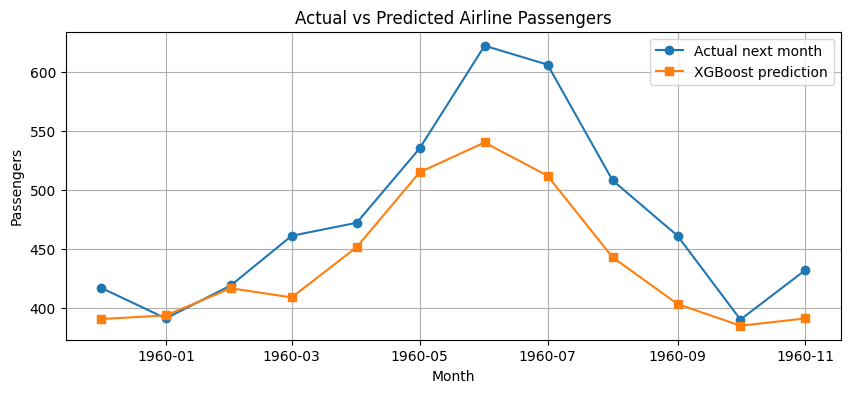

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(results.index, results["target"], marker="o", label="Actual next month")
plt.plot(results.index, results["prediction"], marker="s", label="XGBoost prediction")
plt.title("Actual vs Predicted Airline Passengers")
plt.ylabel("Passengers")
plt.xlabel("Month")
plt.legend()
plt.grid(True)
plt.show()

## 6. Feature Importance and Interpretation
The model uses autoregressive lags, trend smoothing, and seasonality signals to forecast the next month.

- `lag_1` and `lag_12` provide recent and yearly seasonal context.
- Rolling averages and `trend_12` capture the long-term direction.
- `month_sin` / `month_cos` encode periodic seasonality smoothly.

This setup demonstrates how simple time series feature engineering improves a tree-based regressor like XGBoost.

In [15]:
importance = final_model.feature_importances_
importance_df = pd.Series(importance, index=feature_columns).sort_values(ascending=False)
importance_df

lag_12         0.599333
rolling_12     0.323462
month_cos      0.033796
quarter_sin    0.018175
month_sin      0.009915
rolling_3      0.004039
lag_2          0.003710
detrended      0.002846
lag_1          0.002157
rolling_6      0.001952
quarter_cos    0.000616
trend_12       0.000000
dtype: float32

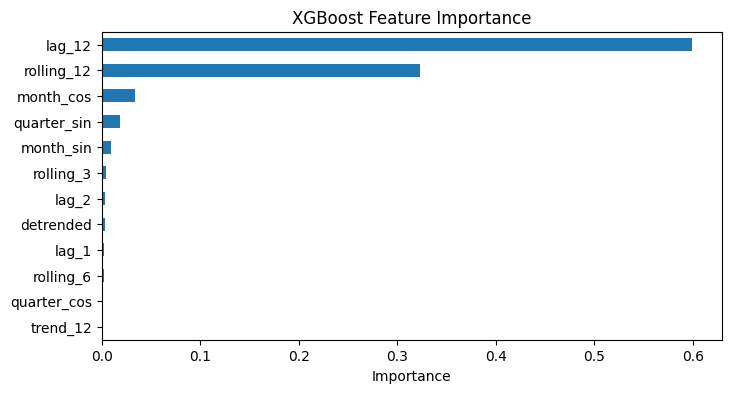

In [16]:
plt.figure(figsize=(8, 4))
importance_df.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()